# Survival tutorial

This tutorial presents the survival analysis workflow in `Exception-Rules`.

The example uses the `18_GBSG2` dataset. The goal is to train a rule-based survival model, inspect the generated rules, and visualize Kaplan-Meier survival estimates.

The file `18_GBSG2.arff` should be located in the same directory as this notebook.


## Optional plotting dependency

The tutorial uses `matplotlib` only for visualizing survival data and Kaplan-Meier curves. If it is not available in your environment, install it by running the next cell.


In [ ]:
%pip install matplotlib

## Dataset

The `18_GBSG2` dataset is a survival dataset stored in ARFF format.

In this tutorial:

- `survival_status` is the event indicator,
- `survival_time` is the survival time attribute,
- all remaining columns are used as descriptive attributes,
- the optional `group` column is removed if present.

The survival status is represented as a string column with values `"0"` and `"1"`.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import arff

from IPython.display import display

from exception_rules.survival.algorithm import MyRuleSurvival

## Load data

The dataset is loaded from the current notebook directory.


In [3]:
dataset_path = Path("18_GBSG2.arff")

df = pd.DataFrame(arff.loadarff(dataset_path)[0])
object_columns = df.select_dtypes([object])

if not object_columns.empty:
    decoded_columns = object_columns.stack().str.decode("utf-8").unstack()

    for column in decoded_columns:
        df[column] = decoded_columns[column].replace({"?": None})

df.head()

,horTh,age,menostat,tsize,tgrade,pnodes,progrec,estrec,survival_time,survival_status
0,no,70.0,Post,21.0,II,3.0,48.0,66.0,1814.0,1.0
1,yes,56.0,Post,12.0,II,7.0,61.0,77.0,2018.0,1.0
2,yes,58.0,Post,35.0,II,9.0,52.0,271.0,712.0,1.0
3,yes,59.0,Post,17.0,II,4.0,60.0,29.0,1807.0,1.0
4,no,73.0,Post,35.0,II,1.0,26.0,65.0,772.0,1.0


## Prepare survival data

The optional `group` column is removed if it is present in the dataset.

The model receives:

- `X`, which contains descriptive attributes and the survival time attribute,
- `y`, which contains the survival status.


In [4]:
if "group" in df.columns:
    df = df.drop(columns=["group"])

survival_time_column = "survival_time"
survival_status_column = "survival_status"

X = df.drop(columns=[survival_status_column])
y = df[survival_status_column].astype(int).astype(str)

print(f"Number of examples: {len(df)}")
print(f"Number of attributes in X: {X.shape[1]}")
print(f"Survival time column: {survival_time_column}")
print(f"Survival status column: {survival_status_column}")

display(y.value_counts().sort_index().rename("count").to_frame())

Number of examples: 686
Number of attributes in X: 9
Survival time column: survival_time
Survival status column: survival_status


,count
survival_status,
0,387
1,299


## Dataset summary

Before training the model, inspect the survival time distribution and the event indicator distribution.


In [5]:
display(X[survival_time_column].describe().rename("survival_time_summary").to_frame())

,survival_time_summary
count,686.000000
mean,1124.489796
std,642.791948
min,8.000000
25%,567.750000
50%,1084.000000
75%,1684.750000
max,2659.000000


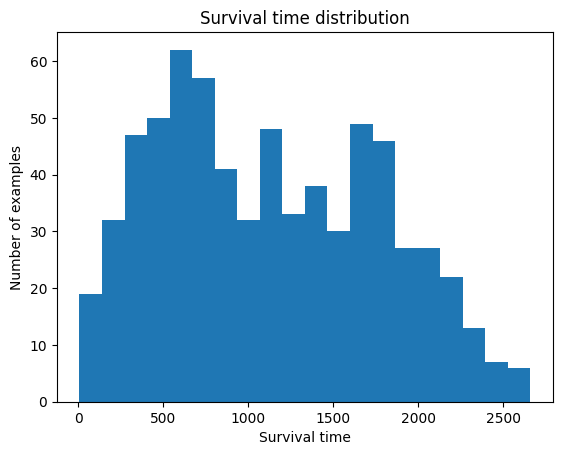

In [6]:
X[survival_time_column].plot(kind="hist", bins=20)
plt.title("Survival time distribution")
plt.xlabel("Survival time")
plt.ylabel("Number of examples")
plt.show()

,count
censored (0),387
event (1),299


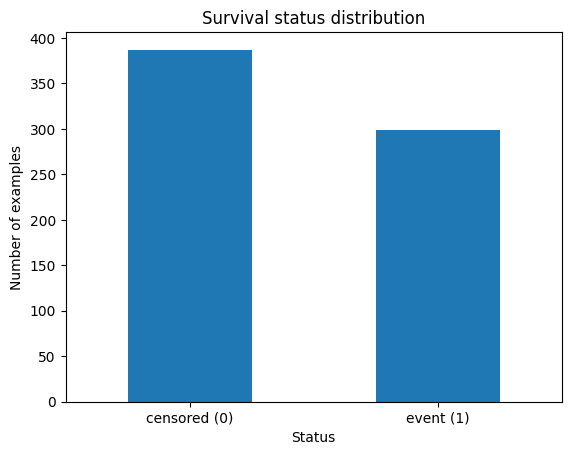

In [7]:
status_distribution = y.value_counts().sort_index().rename("count").to_frame()
status_distribution.index = ["censored (0)", "event (1)"]

display(status_distribution)

status_distribution.plot(kind="bar", legend=False)
plt.title("Survival status distribution")
plt.xlabel("Status")
plt.ylabel("Number of examples")
plt.xticks(rotation=0)
plt.show()

## Train survival model

`MyRuleSurvival` induces commonsense survival rules. When `find_exceptions=True`, it also searches for exception rules and reference rules.

The `survival_time_attr` parameter tells the algorithm which column contains survival times.


In [8]:
survival_model = MyRuleSurvival(
    mincov=5,
    survival_time_attr=survival_time_column,
    max_growing=5,
    find_exceptions=True,
)

model = survival_model.fit(X, y)
ruleset = model.ruleset

print(f"Number of commonsense rules: {len(ruleset.rules)}")

Number of commonsense rules: 2


## Generated rules

Each induced commonsense rule may have a reference rule and an exception rule.

The labels below mean:

- `CR` — commonsense rule,
- `RR` — reference rule,
- `ER` — exception rule.


In [9]:
for rule in ruleset.rules:
    print(f"CR: {rule}")

    if rule.exception_rule is not None:
        print(f"RR: {rule.reference_rule}")
        print(f"ER: {rule.exception_rule}")

    print()

CR: IF pnodes <= 9.50 AND age >= 23.00 THEN survival_status = {2030.0} (p=582, n=0, P=686, N=0)

CR: IF pnodes >= 4.50 THEN survival_status = {893.0} (p=253, n=0, P=686, N=0)
RR: IF progrec <= 2.50 THEN survival_status = {891.0} (p=129, n=0, P=686, N=0)
ER: IF pnodes >= 4.50 AND progrec <= 2.50 THEN survival_status = {624.0} (p=63, n=0, P=686, N=0)



## Rules table

For a more compact view, the same rules can be displayed as a table.

For survival rules, the rule conclusion is a Kaplan-Meier estimator. The table also shows the median survival time estimated for the examples covered by each commonsense rule, if available.


In [10]:
rules_table = pd.DataFrame([
    {
        "commonsense_rule": str(rule),
        "median_survival_time": rule.conclusion.value,
        "reference_rule": str(rule.reference_rule) if rule.reference_rule is not None else "",
        "exception_rule": str(rule.exception_rule) if rule.exception_rule is not None else "",
    }
    for rule in ruleset.rules
])

display(rules_table)

,commonsense_rule,median_survival_time,reference_rule,exception_rule
0,IF pnodes <= 9.50 AND age >= 23.00 THEN surviv...,2030.0,,
1,IF pnodes >= 4.50 THEN survival_status = {893....,893.0,IF progrec <= 2.50 THEN survival_status = {891...,IF pnodes >= 4.50 AND progrec <= 2.50 THEN sur...


## Rule summary

The following table shows how many commonsense rules have an associated exception rule.


In [11]:
rule_summary = pd.DataFrame({
    "metric": [
        "commonsense_rules",
        "rules_with_exceptions",
        "rules_without_exceptions",
    ],
    "value": [
        len(ruleset.rules),
        sum(rule.exception_rule is not None for rule in ruleset.rules),
        sum(rule.exception_rule is None for rule in ruleset.rules),
    ],
})

display(rule_summary)

,metric,value
0,commonsense_rules,2
1,rules_with_exceptions,1
2,rules_without_exceptions,1


## Summary

This tutorial showed how to:

1. load a survival dataset,
2. prepare survival time and survival status columns,
3. train `MyRuleSurvival`,
4. inspect commonsense, reference and exception rules,
5. summarize generated rules

The classification and regression tutorials follow the same documentation style.
